# Ref: https://github.com/langchain-ai/langchain-academy/blob/main/module-1/simple-graph.ipynb

In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# State

In [1]:
from typing import TypedDict

class State(TypedDict):
    graph_state:str

# Nodes

In [2]:
def node_1(state):
    print("---Node 1---")
    return {"graph_state": state['graph_state'] +" I am"}

def node_2(state):
    print("---Node 2---")
    return {"graph_state": state['graph_state'] +" happy!"}

def node_3(state):
    print("---Node 3---")
    return {"graph_state": state['graph_state'] +" sad!"}

# Edges

In [3]:
import random
from typing import Literal

def decide_mood(state) -> Literal["node_2", "node_3"]:
    
    # Often, we will use state to decide on the next node to visit
    user_input = state['graph_state'] 
    
    # Here, let's just do a 50 / 50 split between nodes 2, 3
    if random.random() < 0.5:

        # 50% of the time, we return Node 2
        return "node_2"
    
    # 50% of the time, we return Node 3
    return "node_3"

# Graph Construction

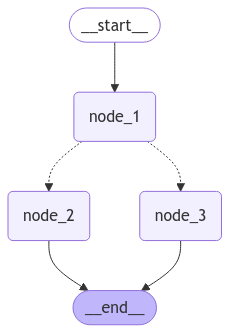

In [4]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END

# Build graph
builder = StateGraph(State)
builder.add_node("node_1", node_1)
builder.add_node("node_2", node_2)
builder.add_node("node_3", node_3)

# Logic
builder.add_edge(START,"node_1")
builder.add_conditional_edges("node_1",decide_mood)
builder.add_edge("node_2",END)
builder.add_edge("node_3",END)

# Compile Graph
graph = builder.compile()

# View Graph
display(Image(graph.get_graph().draw_mermaid_png()))

# Graph Invoke

In [5]:
graph.invoke({"graph_state":"Hi, this is Ankit"})

---Node 1---
---Node 3---


{'graph_state': 'Hi, this is Ankit I am sad!'}